In [1]:
!pip install ipython-autotime

In [2]:
%load_ext autotime

time: 281 µs (started: 2021-09-15 21:39:19 -07:00)


## 4.3 Imports<a id='4.3_Imports'></a>

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

time: 814 ms (started: 2021-09-15 21:39:19 -07:00)


In [4]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_

time: 735 µs (started: 2021-09-15 21:39:20 -07:00)


In [5]:
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

time: 221 µs (started: 2021-09-15 21:39:20 -07:00)


## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [6]:
df_train = rcp('173C_train_split_time_series_merge_173A_and_173B.csv', 
               None)
p(df_train)

(9239, 101)


,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,...,NET_RATING_cma12_diff,pf_cmax999_diff,lc_sum_NET_RATING_cmax999_diff,lc_max_AST_TOV_cmax12_diff,lc_sum_AST_PCT_cmax5_diff,fg3_pct_cma999_diff,ft_pct_cmax12_diff,lc_max_MIN_cmax5_diff,E_NET_RATING_cma5_diff,E_NET_RATING_cmax12_diff
0,-1.045984,2.249661,0.309284,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
1,0.835137,-1.609206,0.383027,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
2,1.138839,-0.562003,1.001028,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
3,-1.256725,0.877570,1.270549,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
4,0.848535,-1.892884,-0.403891,0,6.083854,0,-0.030497,0.030497,6.416819,0.414362,...,-0.879667,4.661921,-0.319484,1.247488,1.691365,8.286999,8.007766,3.521210,-0.677803,-0.598734
9234,1.950338,0.908407,-2.448327,0,1.781375,0,0.163685,-0.163685,-0.176936,1.347733,...,-0.234987,-0.973632,-1.004135,-2.694313,0.931848,0.273061,0.163264,-0.448480,0.130420,0.013153
9235,-0.159237,-0.346823,-0.114386,0,0.464945,0,0.163685,-0.163685,-0.838007,0.414362,...,-0.967409,-0.540128,-1.002372,0.228034,1.378510,0.025707,0.196310,-0.184705,-0.567981,0.543946
9236,0.668894,0.365307,0.609586,0,-1.933986,0,0.059225,-0.059225,0.113645,-1.452381,...,0.552851,0.543632,-1.278631,0.481034,-0.087806,-1.030682,-0.349282,1.555168,-0.463307,-0.900991
9237,-1.178771,-1.458661,-1.226125,0,-0.016676,0,-0.395302,0.395302,0.992650,-0.052324,...,1.152273,0.977137,-0.462101,5.274412,-1.226123,0.139954,-0.431214,0.707843,1.522073,0.507086
9238,-1.593147,1.080693,-1.772901,0,1.203430,0,0.009482,-0.009482,-0.346441,0.881048,...,1.435821,-0.540128,-0.305763,0.053790,-0.145745,1.330639,0.001855,0.458857,0.813377,1.745603


time: 153 ms (started: 2021-09-15 21:39:20 -07:00)


In [7]:
df_test = rcp('173C_test_split_time_series_merge_173A_and_173B.csv', 
              None)
p(df_test)

(1027, 101)


,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,...,NET_RATING_cma12_diff,pf_cmax999_diff,lc_sum_NET_RATING_cmax999_diff,lc_max_AST_TOV_cmax12_diff,lc_sum_AST_PCT_cmax5_diff,fg3_pct_cma999_diff,ft_pct_cmax12_diff,lc_max_MIN_cmax5_diff,E_NET_RATING_cma5_diff,E_NET_RATING_cmax12_diff
0,1.028423,0.322683,1.055866,0,-0.423378,0,-0.094902,0.094902,0.619739,-0.519009,...,-0.323654,0.543632,-0.623327,0.183842,0.547129,-0.093945,-0.615885,0.401065,-1.033010,-1.505506
1,-0.989872,2.184396,-0.524758,0,1.374673,0,-0.239616,0.239616,0.521802,0.881048,...,-1.365485,-0.106624,-1.258891,-0.790590,2.544037,-0.582190,0.316977,1.269063,-1.523778,0.278550
2,0.792883,0.757034,0.660032,0,0.625485,0,-0.091714,0.091714,0.653640,0.414362,...,0.285004,0.326880,1.028775,-0.317461,0.295721,0.448738,-1.731027,-0.381070,0.322609,-0.067941
3,-1.063182,1.568692,0.796300,0,-1.091531,0,-0.355300,0.355300,0.742428,-0.985695,...,1.161510,-0.756880,0.248091,1.364641,0.100918,0.879725,0.404729,0.836795,0.753318,0.853576
4,-0.509033,0.020163,0.452923,0,-0.921539,0,-0.149777,0.149777,0.098895,-0.519009,...,0.792989,-0.973632,0.899901,0.785766,-1.158458,-0.596616,-1.233626,1.533060,1.247518,-0.001591
1022,1.359732,1.106411,-1.506188,0,-0.016676,0,0.009482,-0.009482,0.040681,-0.052324,...,0.854871,-0.973632,0.731619,-1.495076,0.110108,0.406319,0.038192,-0.733868,1.695387,1.480207
1023,1.789289,0.507847,1.893345,0,-0.154391,0,0.009482,-0.009482,0.071918,-0.519009,...,-0.452036,0.543632,1.359431,0.365893,0.047835,-0.323504,-1.048304,-0.077045,-0.640052,-0.849386
1024,1.789289,0.507847,1.893345,0,-0.152875,0,0.009482,-0.009482,0.134429,-0.519009,...,-0.542549,0.543632,1.359431,0.365893,0.047835,-0.339029,-1.110078,-0.077045,-0.730998,-0.849386
1025,-1.790571,0.507847,1.893345,0,-0.151392,0,0.009482,-0.009482,0.070036,-0.519009,...,-0.925847,0.543632,1.359431,0.392504,0.590597,-0.352941,-1.110078,1.181174,-1.566677,-0.849386
1026,-1.790571,0.507847,1.893345,0,-0.149940,0,0.009482,-0.009482,0.006887,-0.519009,...,-1.439374,0.543632,1.359431,0.392504,0.590597,-0.360802,-1.110078,1.195694,-1.915019,-0.849386


time: 31.6 ms (started: 2021-09-15 21:39:20 -07:00)


In [8]:
X_train = df_train.drop(columns = 'spread_a')
p(X_train)

(9239, 100)


,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,...,NET_RATING_cma12_diff,pf_cmax999_diff,lc_sum_NET_RATING_cmax999_diff,lc_max_AST_TOV_cmax12_diff,lc_sum_AST_PCT_cmax5_diff,fg3_pct_cma999_diff,ft_pct_cmax12_diff,lc_max_MIN_cmax5_diff,E_NET_RATING_cma5_diff,E_NET_RATING_cmax12_diff
0,-1.045984,2.249661,0.309284,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
1,0.835137,-1.609206,0.383027,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
2,1.138839,-0.562003,1.001028,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
3,-1.256725,0.877570,1.270549,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,...,-0.026252,0.110128,-0.049559,-0.088860,-0.094422,-0.008676,0.001855,-0.025856,-0.017154,-0.031080
4,0.848535,-1.892884,-0.403891,0,6.083854,0,-0.030497,0.030497,6.416819,0.414362,...,-0.879667,4.661921,-0.319484,1.247488,1.691365,8.286999,8.007766,3.521210,-0.677803,-0.598734
9234,1.950338,0.908407,-2.448327,0,1.781375,0,0.163685,-0.163685,-0.176936,1.347733,...,-0.234987,-0.973632,-1.004135,-2.694313,0.931848,0.273061,0.163264,-0.448480,0.130420,0.013153
9235,-0.159237,-0.346823,-0.114386,0,0.464945,0,0.163685,-0.163685,-0.838007,0.414362,...,-0.967409,-0.540128,-1.002372,0.228034,1.378510,0.025707,0.196310,-0.184705,-0.567981,0.543946
9236,0.668894,0.365307,0.609586,0,-1.933986,0,0.059225,-0.059225,0.113645,-1.452381,...,0.552851,0.543632,-1.278631,0.481034,-0.087806,-1.030682,-0.349282,1.555168,-0.463307,-0.900991
9237,-1.178771,-1.458661,-1.226125,0,-0.016676,0,-0.395302,0.395302,0.992650,-0.052324,...,1.152273,0.977137,-0.462101,5.274412,-1.226123,0.139954,-0.431214,0.707843,1.522073,0.507086
9238,-1.593147,1.080693,-1.772901,0,1.203430,0,0.009482,-0.009482,-0.346441,0.881048,...,1.435821,-0.540128,-0.305763,0.053790,-0.145745,1.330639,0.001855,0.458857,0.813377,1.745603


time: 19.5 ms (started: 2021-09-15 21:39:20 -07:00)


In [9]:
y_train = df_train.spread_a
p(y_train)

(9239,)


0       -8
1       14
2        2
3        1
4      -10
9234    -3
9235   -16
9236   -10
9237   -15
9238   -15
Name: spread_a, dtype: int64

time: 2.12 ms (started: 2021-09-15 21:39:20 -07:00)


In [10]:
X_test = df_test.drop(columns = 'spread_a')
p(X_test)

(1027, 100)


,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,...,NET_RATING_cma12_diff,pf_cmax999_diff,lc_sum_NET_RATING_cmax999_diff,lc_max_AST_TOV_cmax12_diff,lc_sum_AST_PCT_cmax5_diff,fg3_pct_cma999_diff,ft_pct_cmax12_diff,lc_max_MIN_cmax5_diff,E_NET_RATING_cma5_diff,E_NET_RATING_cmax12_diff
0,1.028423,0.322683,1.055866,0,-0.423378,0,-0.094902,0.094902,0.619739,-0.519009,...,-0.323654,0.543632,-0.623327,0.183842,0.547129,-0.093945,-0.615885,0.401065,-1.033010,-1.505506
1,-0.989872,2.184396,-0.524758,0,1.374673,0,-0.239616,0.239616,0.521802,0.881048,...,-1.365485,-0.106624,-1.258891,-0.790590,2.544037,-0.582190,0.316977,1.269063,-1.523778,0.278550
2,0.792883,0.757034,0.660032,0,0.625485,0,-0.091714,0.091714,0.653640,0.414362,...,0.285004,0.326880,1.028775,-0.317461,0.295721,0.448738,-1.731027,-0.381070,0.322609,-0.067941
3,-1.063182,1.568692,0.796300,0,-1.091531,0,-0.355300,0.355300,0.742428,-0.985695,...,1.161510,-0.756880,0.248091,1.364641,0.100918,0.879725,0.404729,0.836795,0.753318,0.853576
4,-0.509033,0.020163,0.452923,0,-0.921539,0,-0.149777,0.149777,0.098895,-0.519009,...,0.792989,-0.973632,0.899901,0.785766,-1.158458,-0.596616,-1.233626,1.533060,1.247518,-0.001591
1022,1.359732,1.106411,-1.506188,0,-0.016676,0,0.009482,-0.009482,0.040681,-0.052324,...,0.854871,-0.973632,0.731619,-1.495076,0.110108,0.406319,0.038192,-0.733868,1.695387,1.480207
1023,1.789289,0.507847,1.893345,0,-0.154391,0,0.009482,-0.009482,0.071918,-0.519009,...,-0.452036,0.543632,1.359431,0.365893,0.047835,-0.323504,-1.048304,-0.077045,-0.640052,-0.849386
1024,1.789289,0.507847,1.893345,0,-0.152875,0,0.009482,-0.009482,0.134429,-0.519009,...,-0.542549,0.543632,1.359431,0.365893,0.047835,-0.339029,-1.110078,-0.077045,-0.730998,-0.849386
1025,-1.790571,0.507847,1.893345,0,-0.151392,0,0.009482,-0.009482,0.070036,-0.519009,...,-0.925847,0.543632,1.359431,0.392504,0.590597,-0.352941,-1.110078,1.181174,-1.566677,-0.849386
1026,-1.790571,0.507847,1.893345,0,-0.149940,0,0.009482,-0.009482,0.006887,-0.519009,...,-1.439374,0.543632,1.359431,0.392504,0.590597,-0.360802,-1.110078,1.195694,-1.915019,-0.849386


time: 16.9 ms (started: 2021-09-15 21:39:20 -07:00)


In [11]:
y_test = df_test.spread_a
p(y_test)

(1027,)


0       13
1        7
2      -10
3      -11
4       10
1022    -9
1023    10
1024    19
1025     8
1026    23
Name: spread_a, dtype: int64

time: 2.13 ms (started: 2021-09-15 21:39:20 -07:00)


## 4.10 Linear Regression Model<a id='4.10_Random_Forest_Model'></a>

In [12]:
pipe = make_pipeline(
    LinearRegression()
)

time: 307 µs (started: 2021-09-15 21:39:20 -07:00)


In [13]:
#linear regression grid search cv
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'linearregression', 'linearregression__copy_X', 'linearregression__fit_intercept', 'linearregression__n_jobs', 'linearregression__normalize'])

time: 1.13 ms (started: 2021-09-15 21:39:20 -07:00)


In [14]:
lr_grid_cv = GridSearchCV(pipe, param_grid={}, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

time: 238 µs (started: 2021-09-15 21:39:20 -07:00)


In [15]:
lr_grid_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('linearregression',
                                        LinearRegression())]),
             n_jobs=-1, param_grid={}, scoring='neg_mean_absolute_error')

time: 1.43 s (started: 2021-09-15 21:39:20 -07:00)


In [16]:
score_mean = lr_grid_cv.cv_results_['mean_test_score']
score_std = lr_grid_cv.cv_results_['std_test_score']

time: 339 µs (started: 2021-09-15 21:39:21 -07:00)


In [17]:
coefs = lr_grid_cv.best_estimator_.named_steps.linearregression.coef_
features = X_train.columns
pd.Series(coefs, index=features).sort_values(ascending=False)

team_id_b_1610612759                          2.692117e+12
away_game_count_day_window999_diff            5.337636e+11
home_game_count_day_window999_diff            4.694416e+11
wins_diff                                     4.251446e+11
losses_diff                                   3.796681e+11
                                                  ...     
future_home_game_percent_day_window12_diff   -5.994733e+11
future_Away_game_percent_day_window12_diff   -5.994733e+11
home_game_percent_day_window999_diff         -1.057898e+12
away_game_percent_day_window999_diff         -1.057898e+12
city_proper_metro_Area_b_San Antonio         -2.692117e+12
Length: 100, dtype: float64

time: 3.7 ms (started: 2021-09-15 21:39:21 -07:00)


In [18]:
lr_neg_mae = cross_validate(lr_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

time: 665 ms (started: 2021-09-15 21:39:21 -07:00)


In [19]:
lr_mae_mean = np.mean(-1 * lr_neg_mae['test_score'])
lr_mae_std = np.std(-1 * lr_neg_mae['test_score'])
lr_mae_mean, lr_mae_std

(9.609963752707586, 0.3629275567296926)

time: 1.65 ms (started: 2021-09-15 21:39:22 -07:00)


In [20]:
mae = mean_absolute_error(y_test, lr_grid_cv.best_estimator_.predict(X_test))
mae

9.724466731221755

time: 7.11 ms (started: 2021-09-15 21:39:22 -07:00)


In [21]:
mape = MAPE(y_test, lr_grid_cv.best_estimator_.predict(X_test))
mape

112.21781822982118

time: 10.6 ms (started: 2021-09-15 21:39:22 -07:00)


In [22]:
#https://datascience.stackexchange.com/questions/12148/feature-importance-via-random-forest-and-linear-regression-are-different

#linear regression variable importance???

#A popular approach to rank a variable's importance in a linear regression model is to decompose 
#R2 into contributions attributed to each variable. 

time: 150 µs (started: 2021-09-15 21:39:22 -07:00)


In [23]:
#https://machinelearningmastery.com/calculate-feature-importance-with-python/

#linear regression feature importance

time: 136 µs (started: 2021-09-15 21:39:22 -07:00)


In [24]:
import sklearn
print(sklearn.__version__)

0.23.2
time: 299 µs (started: 2021-09-15 21:39:22 -07:00)


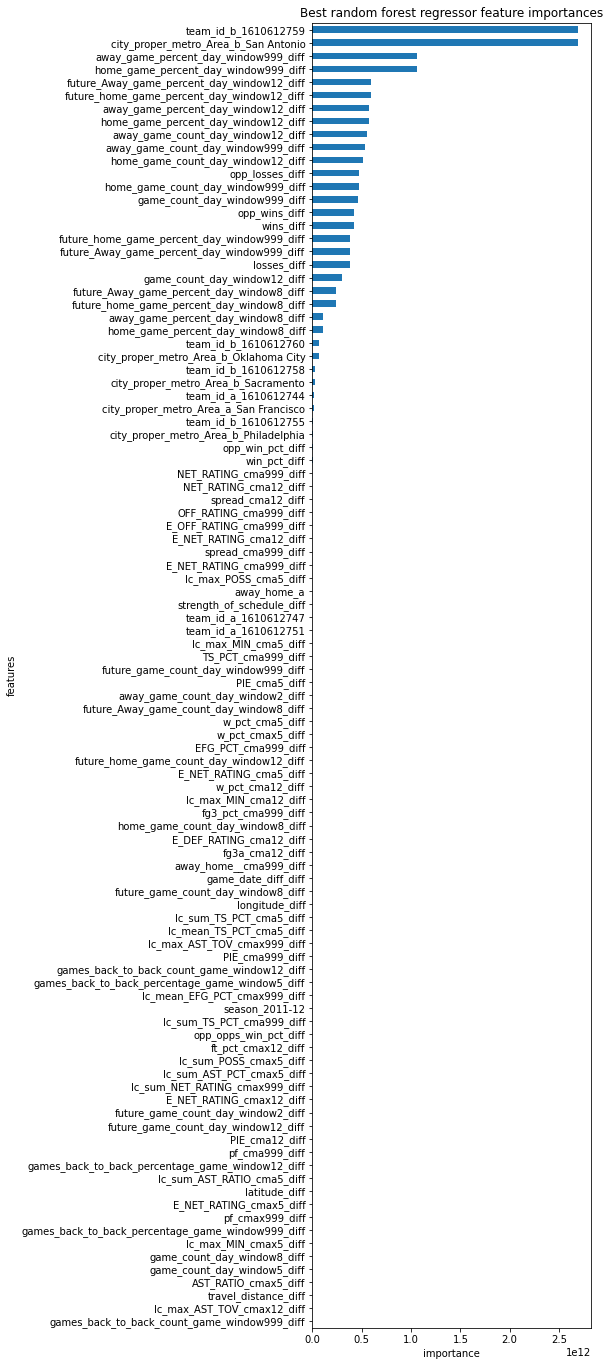

time: 1.12 s (started: 2021-09-15 21:39:22 -07:00)


In [25]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(5, 24))
imps = lr_grid_cv.best_estimator_.named_steps.linearregression.coef_
lr_feat_imps = pd.Series(abs(imps), index=X_train.columns).sort_values(ascending=True)
lr_feat_imps.plot(kind='barh')
plt.xlabel('importance')
plt.ylabel('features')
plt.title('Best random forest regressor feature importances');

## 4.12 Data quantity assessment<a id='4.12_Data_quantity_assessment'></a>

In [26]:
fractions = [.2, .25, .3, .35, .4, .45, .5, .6, .75, .8, 1.0]
train_size, train_scores, test_scores = learning_curve(pipe, X_train, y_train, train_sizes=fractions)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

time: 1.1 s (started: 2021-09-15 21:39:23 -07:00)


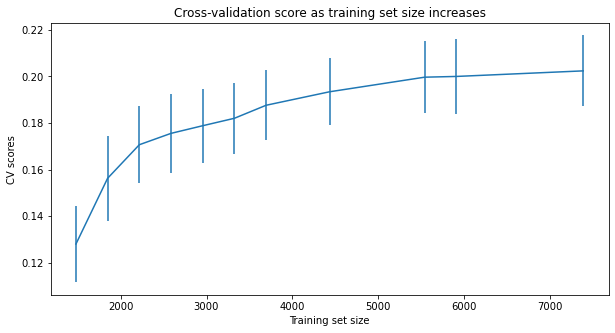

time: 82.6 ms (started: 2021-09-15 21:39:24 -07:00)


In [27]:
plt.subplots(figsize=(10, 5))
plt.errorbar(train_size, test_scores_mean, yerr=test_scores_std)
plt.xlabel('Training set size')
plt.ylabel('CV scores')
plt.title('Cross-validation score as training set size increases');

## 4.13 Save best model object from pipeline<a id='4.13_Save_best_model_object_from_pipeline'></a>

In [28]:
#This may not be "production grade ML deployment" practice, but adding some basic
#information to your saved models can save your bacon in development.
#Just what version model have you just loaded to reuse? What version of `sklearn`
#created it? When did you make it?
#Assign the pandas version number (`pd.__version__`) to the `pandas_version` attribute,
#the numpy version (`np.__version__`) to the `numpy_version` attribute,
#the sklearn version (`sklearn_version`) to the `sklearn_version` attribute,
#and the current datetime (`datetime.datetime.now()`) to the `build_datetime` attribute
#Let's call this model version '1.0'
best_model = lr_grid_cv.best_estimator_
best_model.version = '1.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train.columns]
best_model.build_datetime = datetime.datetime.now()
    
modelpath = os.path.join('..', 'models')
if not os.path.exists(modelpath):
    os.mkdir(modelpath)
nbamodel_path = os.path.join(modelpath, '173C_linear_regression_model_trial_1.pkl')
if not os.path.exists(nbamodel_path):
    with open(nbamodel_path, 'wb') as f:
        pickle.dump(best_model, f)

time: 835 µs (started: 2021-09-15 21:39:24 -07:00)


In [29]:
mape

112.21781822982118

time: 1.06 ms (started: 2021-09-15 21:39:24 -07:00)


In [30]:
mae

9.724466731221755

time: 949 µs (started: 2021-09-15 21:39:24 -07:00)


## 4.14 Concluding Thoughts<a id='4.13_Save_best_model_object_from_pipeline'></a>